# Light leaves and double leaves

The morphism layer: subexpressions, the Libedinsky light-leaf construction,
double leaves, and the Zamolodchikov cycle in type A₃. This is the only layer
that uses `CoxeterGroups.jl` (for short-lex normal forms and descent
decisions).

In [1]:
using DiagrammaticHecke
debug_labels(true)

true

## 1. Braid moves on reduced words

`braid_move_sites`, `apply_braid_move` and `reex_graph` handle reduced words
combinatorially; `braid_to_end_with` rotates a word to end in a chosen right
descent — the step the light-leaf induction needs before a down-move.

In [2]:
w0 = [1,2,1,3,2,1]
@show is_reduced(w0) braid_move_sites(w0)
@show braid_to_end_with(w0, 3)
words, edges = reex_graph(w0)
length(words)   # 16 reduced words for the longest element

is_reduced(w0) = 

true


braid_move_sites(w0) = [(1, 3), (3, 4)]


braid_to_end_with(w0, 3) = ([2, 1, 3, 2, 1, 3], [(1, 3), (3, 5), (5, 6)])


16

## 2. Subexpressions and decorations

A subexpression `e ∈ {0,1}^k` of a word walks the Bruhat order; each letter
gets a decoration U0/U1/D0/D1, and the `defect` (number of D1 minus … — see
the docstring) is the degree of the resulting light leaf.

In [3]:
x = [1,2,1]
for e in subexpressions(3)
    println(e, " → ", decorations(x, e), "  expresses ", expressed_word(x, e),
            "  defect ", defect(x, e))
end

[0, 0, 0] → 

[:U0, :U0, :U0]  expresses Int64[]  defect 3
[1, 0, 0] → [:U1, :U0, :D0]  expresses [1]  defect 0
[0, 1, 0] → [:U0, :U1, :U0]  expresses [2]  defect 2
[1, 1, 0] → [:U1, :U1, :U0]  expresses [1, 2]  defect 1
[0, 0, 1] → [:U0, :U0, :U1]  expresses [1]  defect 2
[1, 0, 1] → [:U1, :U0, :D1]  expresses Int64[]  defect 1
[0, 1, 1] → [:U0, :U1, :U1]  expresses [2, 1]  defect 1
[1, 1, 1] → [:U1, :U1, :U1]  expresses [1, 2, 1]  defect 0


## 3. Light leaves

`light_leaf(x, e)` is the morphism `BS(x) → BS(expressed_word(x, e))`, built
letter by letter from the four decoration cases. Every cell below draws the
diagram.

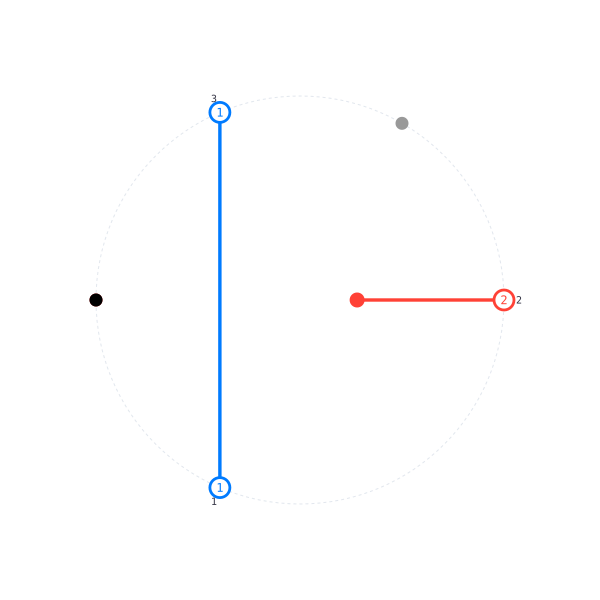

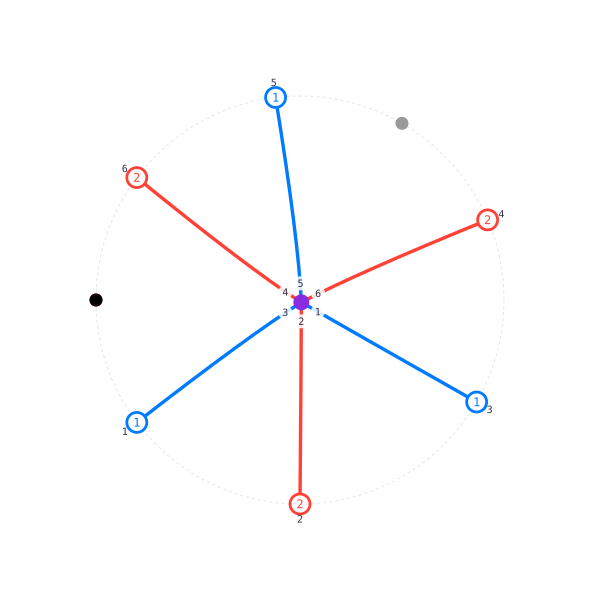

bottom(l4) = [1, 2, 1, 2]
top(l4) = [2, 1]


In [4]:
l = light_leaf([1,2,1], [1,0,1])   # top = ε, needs a genuine cap
display(l)
l4 = light_leaf([1,2,1,2], [1,1,1,1])   # braids before the cap
display(l4)
@show bottom(l4) top(l4);

A longer word shows more. On `12321` the subexpression `[1,0,1,0,0]` walks
down to `13` with defect 1 and uses four of the five letters non-trivially: two
`U1` steps that just carry a strand through, two `U0` steps that each cap one
with a dot, and a closing `D0`. Five nodes instead of one.

is_reduced(xb) = true


decorations(xb, eb) = [:U1, :U0, :U1, :U0, :D0]
expressed_word(xb, eb) = [1, 3]
defect(xb, eb) = 1
bottom(lb) = [1, 2, 3, 2, 1]
top(lb) = [1, 3]
length(lb.graph.nodes) = 5


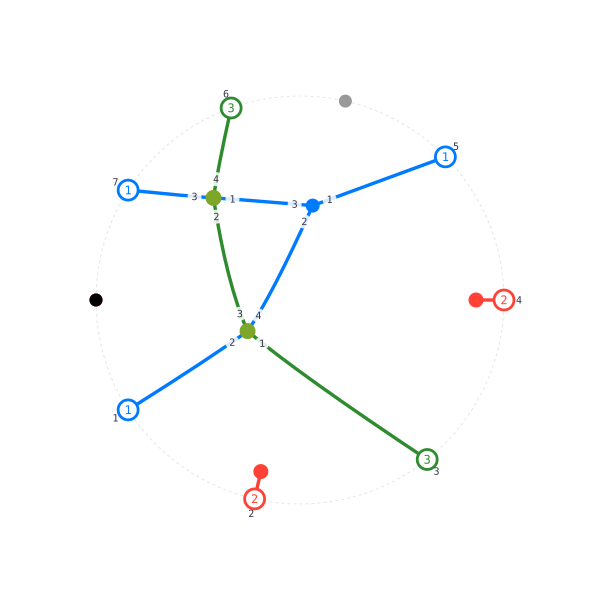

In [5]:
xb, eb = [1,2,3,2,1], [1,0,1,0,0]
@show is_reduced(xb) decorations(xb, eb) expressed_word(xb, eb) defect(xb, eb)
lb = light_leaf(xb, eb)
@show bottom(lb) top(lb) length(lb.graph.nodes)
display(lb)

## 4. Double leaves

`double_leaf(x, e, y, f)` glues a light leaf and a flipped one along their
common expressed element; `double_leaves(x, y)` enumerates the whole basis of
`Hom(BS(x), BS(y))`. Its size matches the Hecke-algebra pairing table
(notebook 02, §5) — e.g. 12 for x = y = 121.

length(dls) = 12


expected_count([1, 2, 1], [1, 2, 1]) = 12
d.degree = 4
degree(d.morphism) = 

4


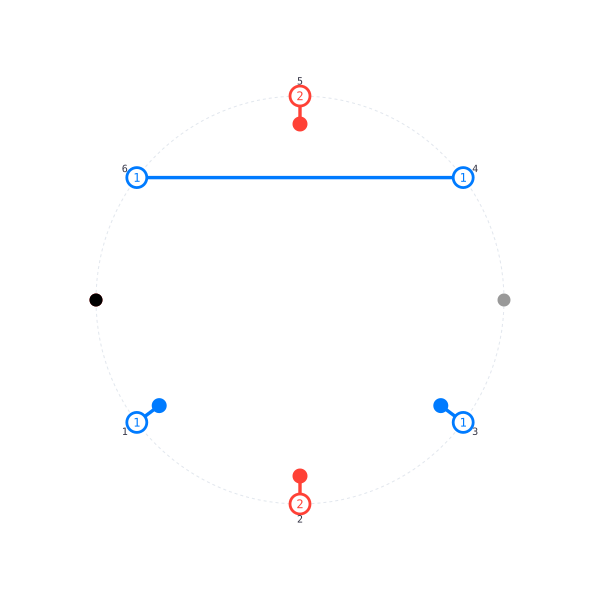

In [6]:
dls = double_leaves([1,2,1], [1,2,1])
@show length(dls) expected_count([1,2,1], [1,2,1])
d = dls[3]
@show d.degree degree(d.morphism)
display(d.morphism)

The same for a double leaf. Over `12321` the basis has 68 elements; number 14
glues two light leaves through the intermediate element `13` and comes out with
ten nodes — dots, trivalents and a braid in one picture.

length(double_leaves(xb, xb)) = 68
expected_count(xb, xb) = 68
dlb.e = [1, 0, 1, 0, 0]
dlb.f = [1, 0, 1, 0, 0]
dlb.z = [1, 3]
dlb.degree = 2
length(dlb.morphism.graph.nodes) = 10


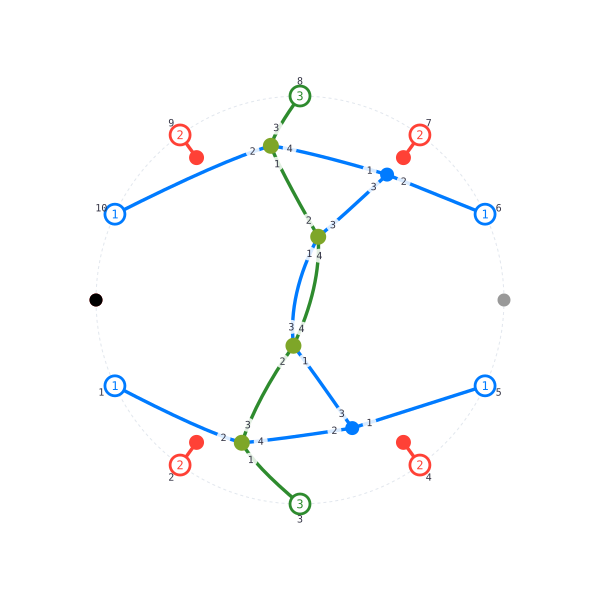

In [7]:
dlb = double_leaves(xb, xb)[14]
@show length(double_leaves(xb, xb)) expected_count(xb, xb)
@show dlb.e dlb.f dlb.z dlb.degree length(dlb.morphism.graph.nodes)
display(dlb.morphism)

## 5. The Zamolodchikov cycle

The 14 reduced words of `w₀` reachable by single braid moves close into a
cycle; `Zamo(i, j)` is the walk from word `i` to word `j` (one braid node per
step). The relation `zamo_lhs() = zamo_rhs()` (both `121321 → 321323`, 7 nodes
each) is the A₃ Zamolodchikov relation the rewrite rules treat as an axiom.

length(zamo_words()) = 14


zamo_relation_endpoints_agree() = true


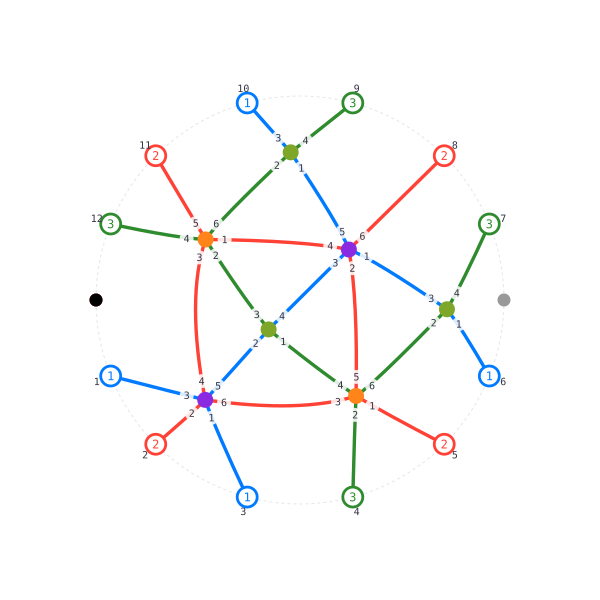

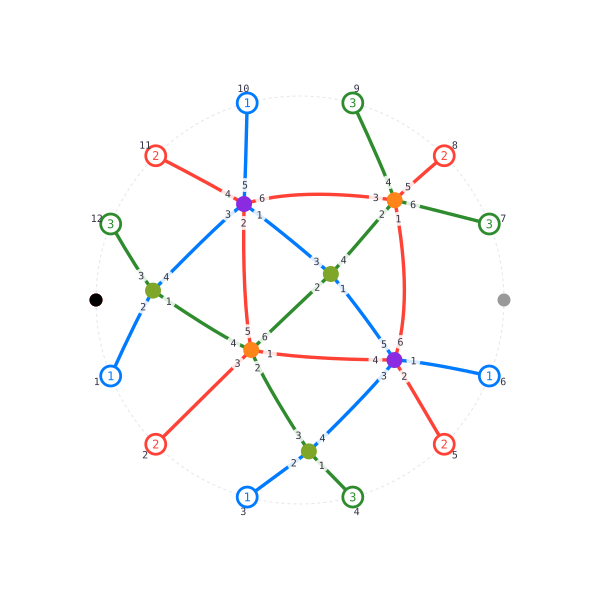

In [8]:
@show length(zamo_words()) zamo_relation_endpoints_agree()
display(zamo_lhs())
display(zamo_rhs())